# Regression like transfer function- Linear Model

In [1]:
import numpy as np
import xarray as xr
import regionmask
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.waves.estela import ESTELA
from utils.data import load_atmospheric_predictor
from utils.funcs_linear import fit_plot_linear_model, plot_pcs, plot_waves

## Predictor- Load large scale atmospheric variables
### mean sea level pressure, spatial gradient of mean sea level pressure

In [2]:
# Define the variables and region
variables = ["msl", "msl_gradient"]
region = (10, 28, 40, 42)
estela = False

# Load the ERA5 predictors
era5 = load_atmospheric_predictor(variables=variables, region=region, estela=estela)
mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(
    era5.rename({"longitude": "lon", "latitude": "lat"})
)
era5["mask"] = mask.rename({"lon": "longitude", "lat": "latitude"})
era5 = era5.where(era5.mask != 0)
era5

<xarray.Dataset> Size: 54MB
Dimensions:       (time: 14610, latitude: 15, longitude: 31)
Coordinates:
  * latitude      (latitude) float32 60B 42.0 41.0 40.0 39.0 ... 30.0 29.0 28.0
  * longitude     (longitude) float32 124B 10.0 11.0 12.0 ... 38.0 39.0 40.0
  * time          (time) datetime64[s] 117kB 1979-01-01 ... 2018-12-31
Data variables:
    msl           (time, latitude, longitude) float32 27MB 9.992e+04 ... nan
    msl_gradient  (time, latitude, longitude) float32 27MB 3.539e+05 ... nan
    mask          (latitude, longitude) float64 4kB nan nan nan ... nan nan nan
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [3]:
# # If cell above takes too long, run:
# !wget https://geoocean.sci.unican.es/data/era5_predictor_aveiro.nc -P inputs/

# # Then run:
# era5 = xr.open_dataset("inputs/era5_predictor_aveiro.nc")
# mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(
#     era5.rename({"longitude": "lon", "latitude": "lat"})
# )
# era5["mask"] = mask.rename({"lon": "longitude", "lat": "latitude"})
# era5 = era5.where(era5.mask != 0)
# era5

## Predictor- define indices/covariates/input layers
### PCA- Principal Component Analysis + reduce dimensionality

In [4]:
pca = PCA(n_components=0.9)

_pcs = pca.fit_transform(
    data=era5,
    vars_to_stack=["msl", "msl_gradient"],
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
    value_to_replace_nans={"msl": 101325.0, "msl_gradient": 0.0},
)
_pcs

2025-10-16 09:58:18,351 - PCA - WARNING - Using 191 out of 465 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-10-16 09:58:18,367 - PCA - WARNING - Using 191 out of 465 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 1MB
Dimensions:      (time: 14610, n_component: 18)
Coordinates:
  * time         (time) datetime64[s] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
  * n_component  (n_component) int64 144B 0 1 2 3 4 5 6 ... 11 12 13 14 15 16 17
Data variables:
    PCs          (time, n_component) float32 1MB -19.0 20.32 ... -0.2719
    stds         (n_component) float32 72B 11.8 7.943 6.766 ... 1.705 1.59 1.531

### PCA- spatial modes EOF

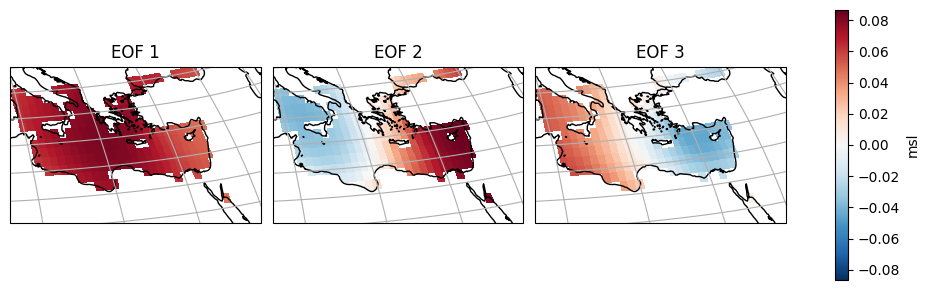

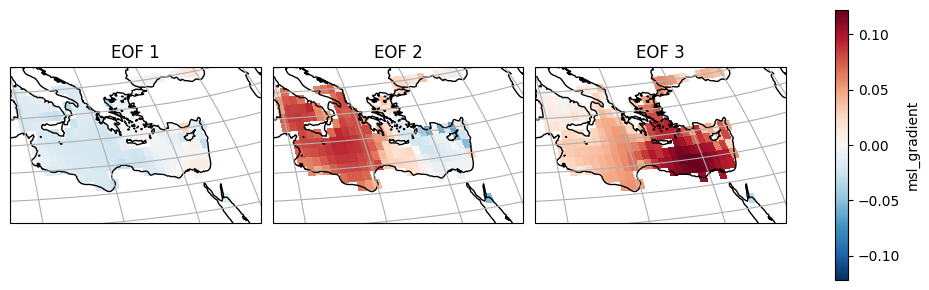

In [5]:
pca.plot_eofs(num_eofs=3, vars_to_plot=["msl", "msl_gradient"], map_center=(-10, 10))

### PCA- temporal indices PCs

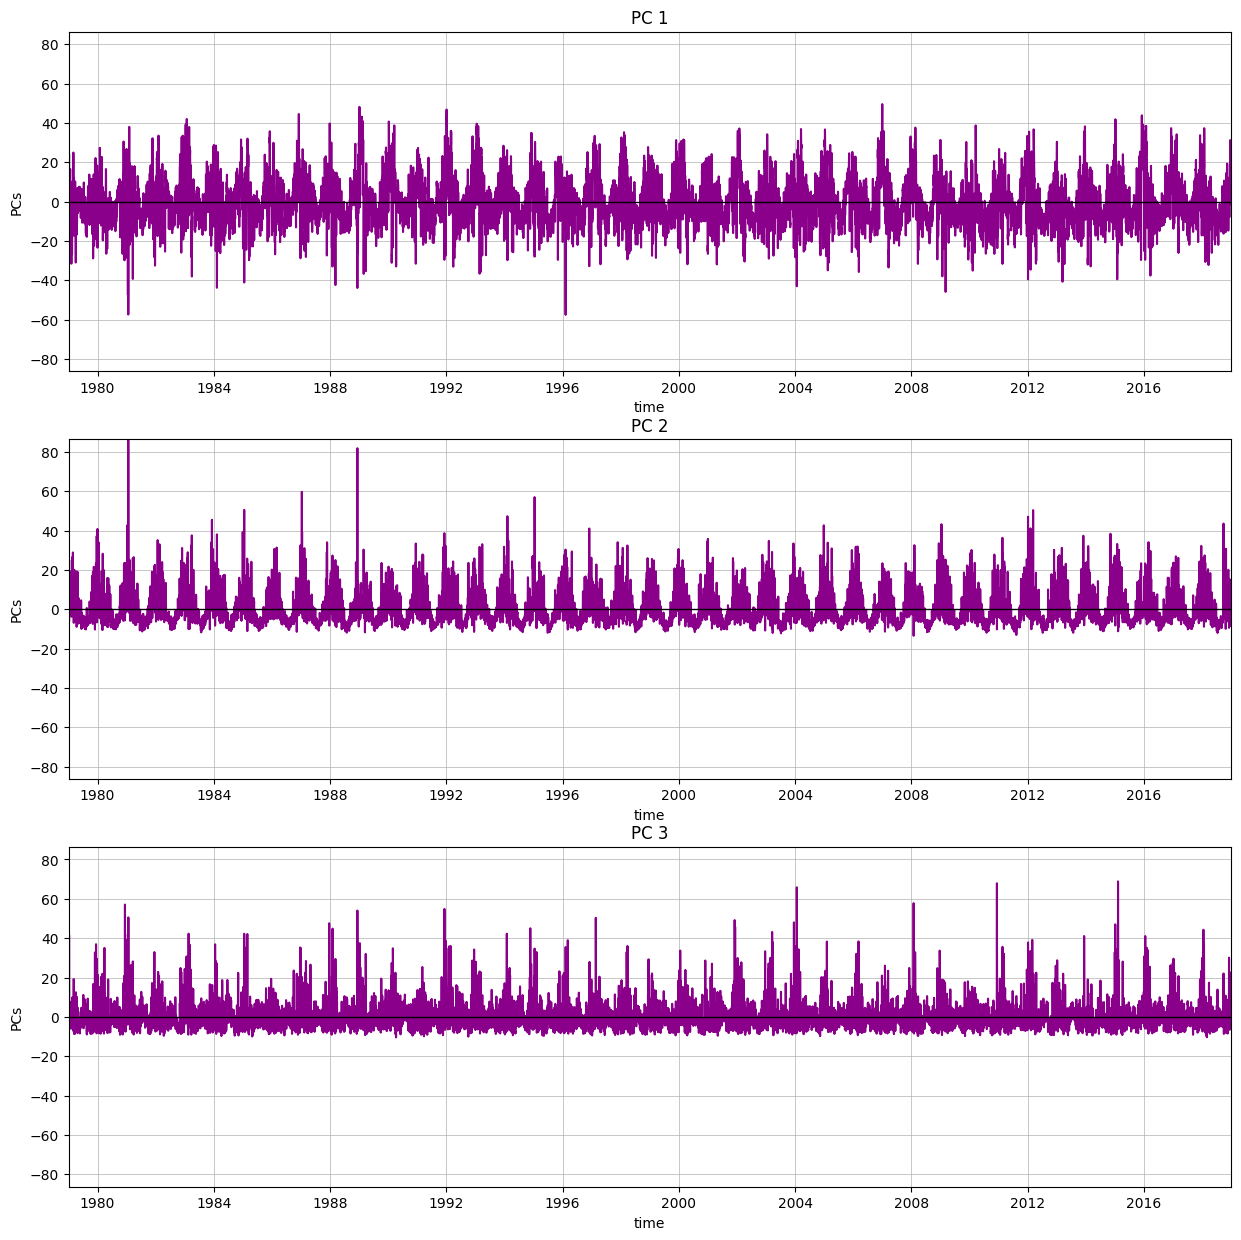

In [6]:
n_pcs = 3
plot_pcs(pca, n_pcs)

## Predictand- Load regional/local wave data
### significant wave height, peak period

In [7]:
waves = xr.open_dataset("inputs/daily_predictand_1979_2018.nc").rename({'pp1d':'tp','mwd':'dir'})
waves['EF'] = (waves.swh**2) * waves.tp
waves = waves[['swh', 'EF', 'ss']]

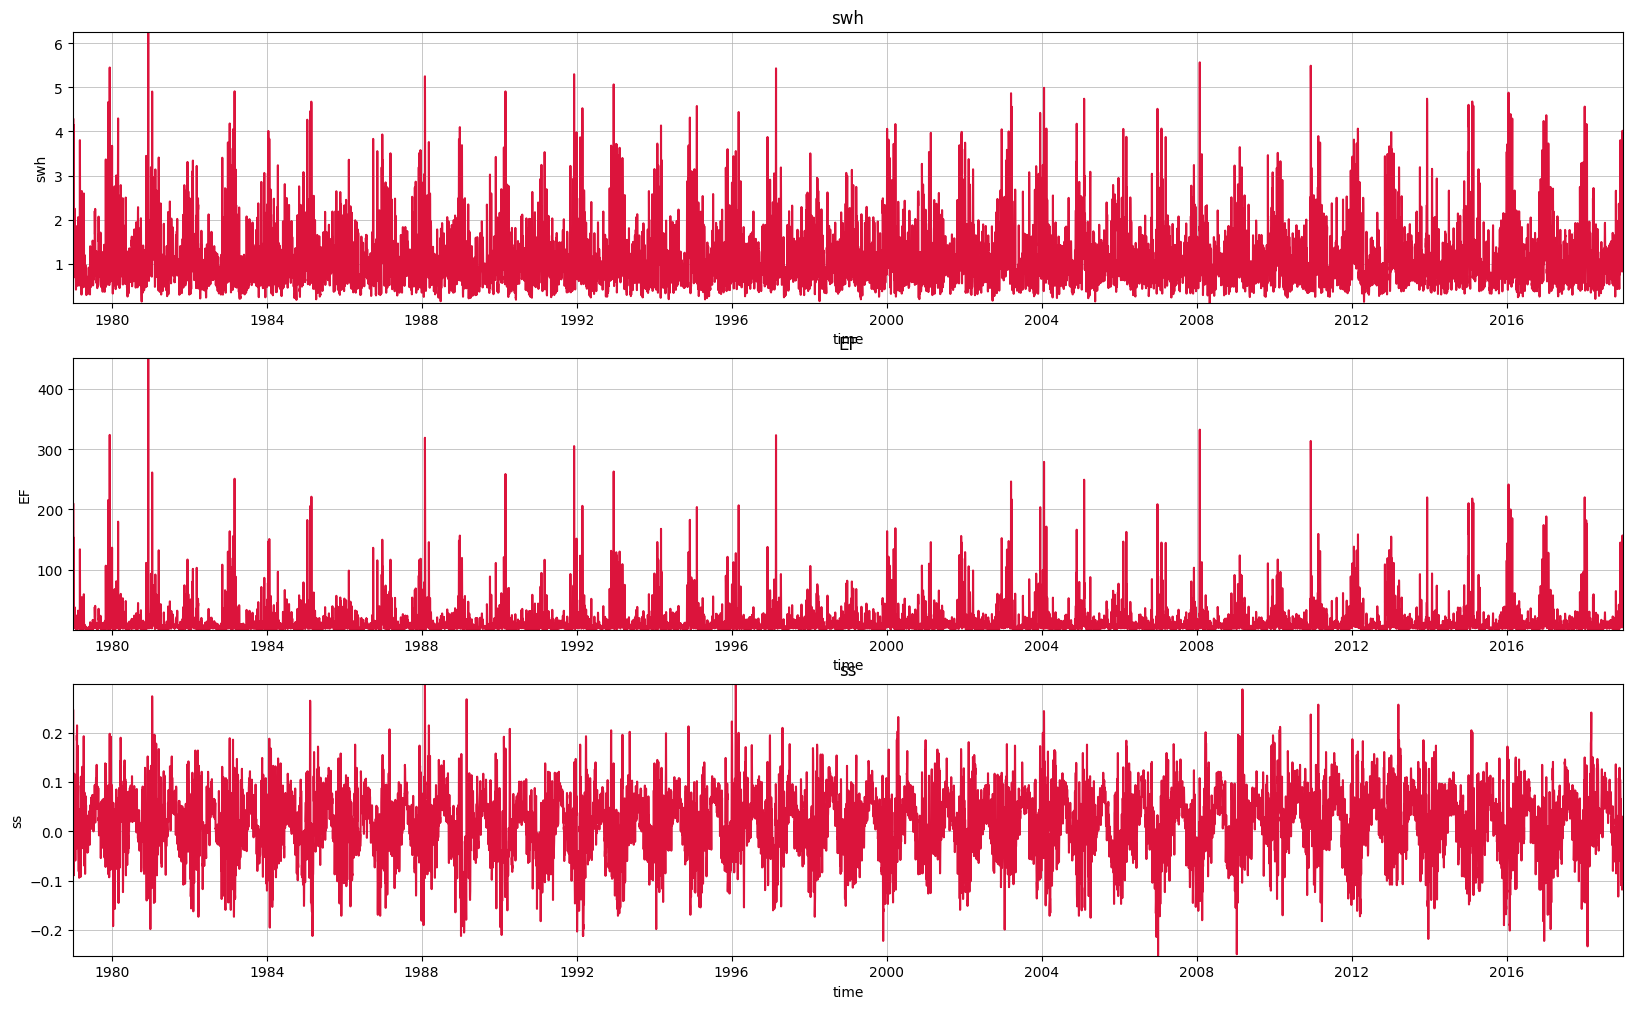

In [8]:
plot_waves(waves)

## Predictand to Predictor - Model
### Multiple Linear Regression
X - temporal indices PCs- Predictor: regressors, exogenous variables, explanatory variables, covariates, input variables, predictor variables, or independent variables

Y - wave parameter- Predictand: regressand, endogenous variable, response variable, target variable, measured variable, criterion variable, or dependent variable

In [9]:
pca.pcs

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 14610, n_component: 18)
Coordinates:
  * time         (time) datetime64[s] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
  * n_component  (n_component) int64 144B 0 1 2 3 4 5 6 ... 11 12 13 14 15 16 17
Data variables:
    PCs          (time, n_component) float32 1MB -19.0 20.32 ... -0.2719
    stds         (n_component) float32 72B 11.8 7.943 6.766 ... 1.705 1.59 1.531

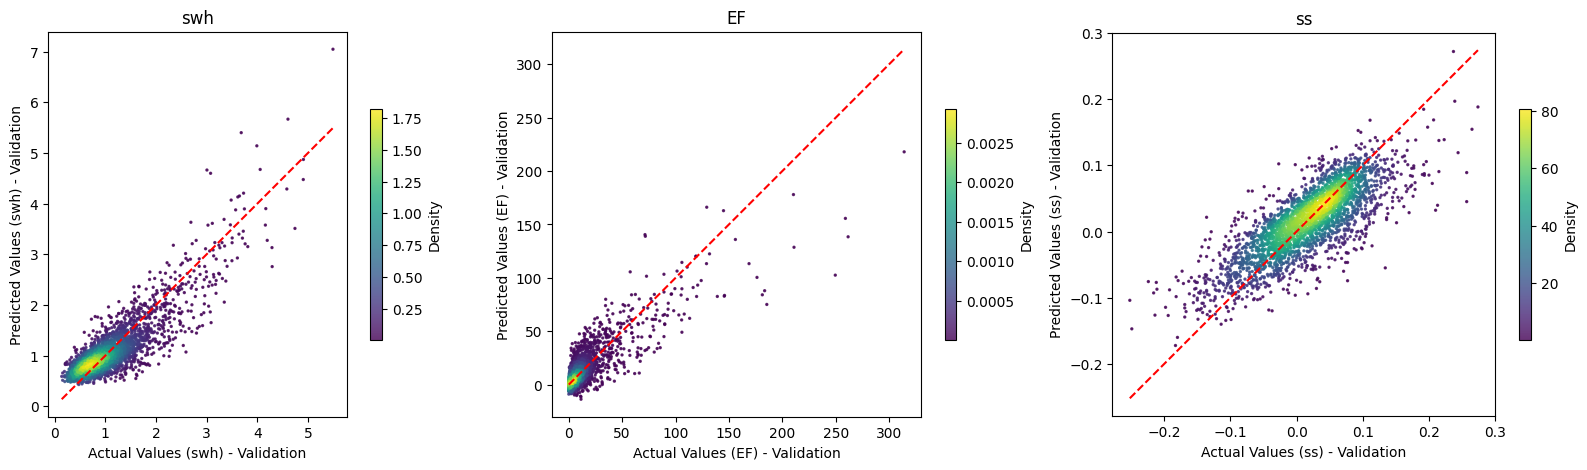

In [10]:
n_pcs = pca.pca.n_components_  # This is the number of PCs to use as X

common_times = np.intersect1d(pca.pcs.time, waves.time)

X = pca.pcs.sel(time=common_times).PCs.isel(n_component=range(n_pcs)).values
Ys = waves.sel(time=common_times).to_dataframe()[waves.data_vars.keys()].values

fit_plot_linear_model(X, Ys, keys=list(waves.data_vars.keys()), perc_train=0.8)